# What are the most optimal skills to learn for Data Roles?

#### Methodology
1. Continue from the last notebook to find the percent of postings with each skill.
2. Visualize median salary vs. skill demand for Data Analyst, Data Scientist, and Data Engineer roles in Australia.
3. Determine whether certain technologies are more prevalent across those skills.


## Import Libraries and Data

Import the libraries, data and change the `job_posted_date` to a datetime type.

In [1]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


Filters the original dataset to get rows where the job title is Data Analyst, Data Scientist, or Data Engineer, and the country is Australia.


In [2]:
# Filter for Data Analyst, Data Scientist, Data Engineer in Australia
df_filtered = df[
    (df['job_title_short'].isin(['Data Analyst', 'Data Scientist', 'Data Engineer'])) &
    (df['job_country'].isin(['Australia']))
].copy()

# Drop NaN values from the 'salary_year_avg' column for accurate visualization
df_filtered = df_filtered.dropna(subset=['salary_year_avg'])

df_exploded = df_filtered.explode('job_skills')

df_exploded[['salary_year_avg', 'job_skills']].head(5)


,salary_year_avg,job_skills
27637,147500.0,sql
27637,147500.0,python
27637,147500.0,atlassian
42522,135000.0,sql
42522,135000.0,snowflake


## Calculate Percent of Job Postings that Have Skills

Group the data by skill and calculate both the count and median salary for the combined target roles in Australia. The grouped result is reset to a regular column structure so the skill name can be used consistently in later merges and plots.


In [3]:
# Aggregate skill counts and median salary for the target roles
df_skills = df_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).reset_index()
df_skills = df_skills.rename(columns={'count': 'skill_count', 'median': 'median_salary'})
df_skills = df_skills.sort_values(by='skill_count', ascending=False)

job_count = len(df_filtered)  # Count Australia job postings with salary info for the target roles

df_skills['skill_percent'] = df_skills['skill_count'] / job_count * 100

df_skills = df_skills[df_skills['skill_count'] > 0]

df_skills


,job_skills,skill_count,median_salary,skill_percent
53,sql,32,116750.0,78.048780
43,python,28,119250.0,68.292683
4,aws,15,125000.0,36.585366
5,azure,14,100354.0,34.146341
51,snowflake,9,100500.0,21.951220
...,...,...,...,...
32,nltk,1,120000.0,2.439024
33,node.js,1,147500.0,2.439024
35,numpy,1,120000.0,2.439024
36,opencv,1,120000.0,2.439024


## Median Salary vs Percent Skill Demand

Filters for skills that exceed a chosen demand threshold within the Australia target-role dataset.


In [4]:
skill_limit = 5
min_skill_count = 8

df_skills_high_demand = df_skills[
    (df_skills['skill_percent'] > skill_limit) &
    (df_skills['skill_count'] >= min_skill_count)
].copy()


Create a scatter plot to visualize the relationship between demand and pay for frequently requested skills in Australia. To reduce noise, only skills above the demand threshold and minimum skill-count threshold are plotted.


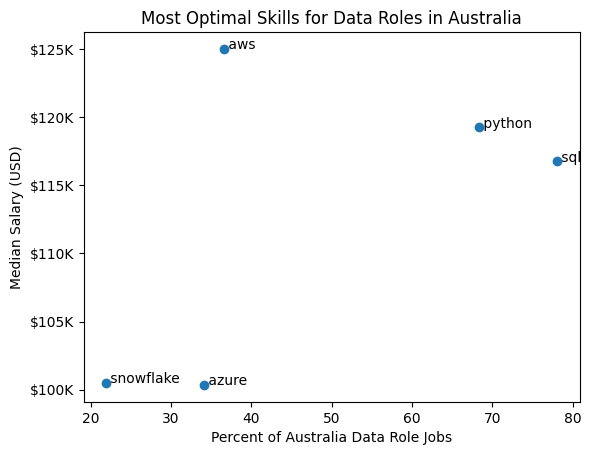

In [5]:
try:
    from adjustText import adjust_text
except ModuleNotFoundError:
    adjust_text = None

plt.scatter(df_skills_high_demand['skill_percent'], df_skills_high_demand['median_salary'])
plt.xlabel('Percent of Australia Data Role Jobs')
plt.ylabel('Median Salary (USD)')
plt.title('Most Optimal Skills for Data Roles in Australia')

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))

texts = []
for _, row in df_skills_high_demand.iterrows():
    texts.append(plt.text(row['skill_percent'], row['median_salary'], ' ' + row['job_skills']))

if adjust_text is not None:
    adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

plt.show()


## Optimal Skills in Australia
Visualizing the most optimal skills (high demand and high salary) for the selected data roles in Australia.


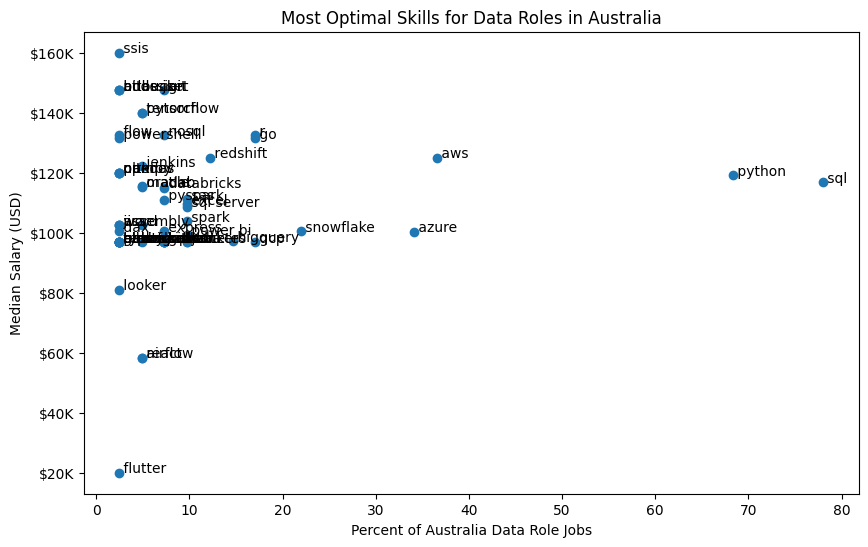

In [6]:
countries = ['Australia']
for country in countries:
    df_country = df_exploded[df_exploded['job_country'] == country].copy()

    df_skills_country = df_country.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).reset_index()
    df_skills_country = df_skills_country.rename(columns={'count': 'skill_count', 'median': 'median_salary'})
    df_skills_country = df_skills_country.sort_values(by='skill_count', ascending=False)

    country_job_count = len(df_filtered[df_filtered['job_country'] == country])
    df_skills_country['skill_percent'] = df_skills_country['skill_count'] / country_job_count * 100
    df_skills_country = df_skills_country[df_skills_country['skill_count'] > 0]

    skill_limit_country = 2
    df_skills_country_high = df_skills_country[df_skills_country['skill_percent'] > skill_limit_country].copy()

    plt.figure(figsize=(10, 6))
    plt.scatter(df_skills_country_high['skill_percent'], df_skills_country_high['median_salary'])
    plt.xlabel('Percent of Australia Data Role Jobs')
    plt.ylabel('Median Salary (USD)')
    plt.title(f'Most Optimal Skills for Data Roles in {country}')

    ax = plt.gca()
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))

    texts = []
    for _, row in df_skills_country_high.iterrows():
        texts.append(plt.text(row['skill_percent'], row['median_salary'], ' ' + row['job_skills']))

    if adjust_text is not None:
        adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

    plt.show()


## Bonus: Coloring by Technology

We're going to add color labels based on technology.

Removes duplicate entries and any rows with missing values. Then, it combines all dictionary entries into a single dictionary, summing values for keys that repeat across entries. To ensure each key's values are unique, it converts the values to a set and then back to a list. The final result is a dictionary where each key represents a skill and each value is a list of unique attributes associated with that skill.

In [7]:
df_technology = df['job_type_skills'].copy()

# remove duplicates
df_technology = df_technology.drop_duplicates()

# remove NaN values
df_technology = df_technology.dropna()

# combine all dictionaries into one
technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row)  # convert string to dictionary
    for key, value in row_dict.items():
        if key in technology_dict:  # if key already exists in technology_dict, add value to existing value
            technology_dict[key] += value
        else:                       # if key does not exist in technology_dict, add key and value
            technology_dict[key] = value

# remove duplicates by converting values to set then back to list
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

technology_dict

{'analyst_tools': ['visio',
  'excel',
  'power bi',
  'word',
  'sas',
  'msaccess',
  'powerpoint',
  'alteryx',
  'nuix',
  'splunk',
  'qlik',
  'ms access',
  'powerbi',
  'cognos',
  'microstrategy',
  'spreadsheet',
  'dax',
  'ssrs',
  'looker',
  'sheets',
  'sharepoint',
  'ssis',
  'tableau',
  'datarobot',
  'sap',
  'outlook',
  'esquisse',
  'spss'],
 'programming': ['html',
  'cobol',
  'objective-c',
  'clojure',
  'c#',
  'bash',
  'kotlin',
  'powershell',
  'nosql',
  'sql',
  'fortran',
  'lisp',
  'assembly',
  'sas',
  'matlab',
  'mongo',
  'delphi',
  'golang',
  'lua',
  'dart',
  'ocaml',
  'f#',
  'typescript',
  'pascal',
  'r',
  'sass',
  'go',
  'solidity',
  'c',
  'erlang',
  'visualbasic',
  'perl',
  'css',
  'ruby',
  'vb.net',
  'rust',
  'java',
  'mongodb',
  'swift',
  'elixir',
  'c++',
  'python',
  'apl',
  'julia',
  'scala',
  'javascript',
  'vba',
  'shell',
  'php',
  'haskell',
  'groovy',
  'visual basic',
  't-sql',
  'no-sql',
  'crys

This code converts a dictionary into a pandas DataFrame, then explodes the 'skills' column, creating multiple rows for each 'technology' entry if it contains multiple skills.

In [8]:
# turn dictionary into dataframe
df_technology = pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])

df_technology = df_technology.explode('skills')

df_technology


,technology,skills
0,analyst_tools,visio
0,analyst_tools,excel
0,analyst_tools,power bi
0,analyst_tools,word
0,analyst_tools,sas
...,...,...
9,sync,microsoft teams
9,sync,slack
9,sync,unify
9,sync,wire


Merges the Australia skill summary with the technology lookup so the scatter plot can be colored by technology category.


In [9]:
# merge df_skills and df_technology
df_skills_tech = df_skills.merge(df_technology, left_on='job_skills', right_on='skills', how='left')
df_skills_tech = df_skills_tech.dropna(subset=['technology'])

df_skills_tech


,job_skills,skill_count,median_salary,skill_percent,technology,skills
0,sql,32,116750.0,78.048780,programming,sql
1,python,28,119250.0,68.292683,programming,python
2,aws,15,125000.0,36.585366,cloud,aws
3,azure,14,100354.0,34.146341,cloud,azure
4,snowflake,9,100500.0,21.951220,cloud,snowflake
...,...,...,...,...,...,...
57,nltk,1,120000.0,2.439024,libraries,nltk
58,node.js,1,147500.0,2.439024,webframeworks,node.js
59,numpy,1,120000.0,2.439024,libraries,numpy
60,opencv,1,120000.0,2.439024,libraries,opencv


Filters the technology-enriched skill summary to keep only skills above the selected demand threshold.


In [10]:
df_skills_tech_high_demand = df_skills_tech[
    (df_skills_tech['skill_percent'] > skill_limit) &
    (df_skills_tech['skill_count'] >= min_skill_count)
].copy()


Plot the results in a scatter plot, coloring the points based on the 'technology' column.

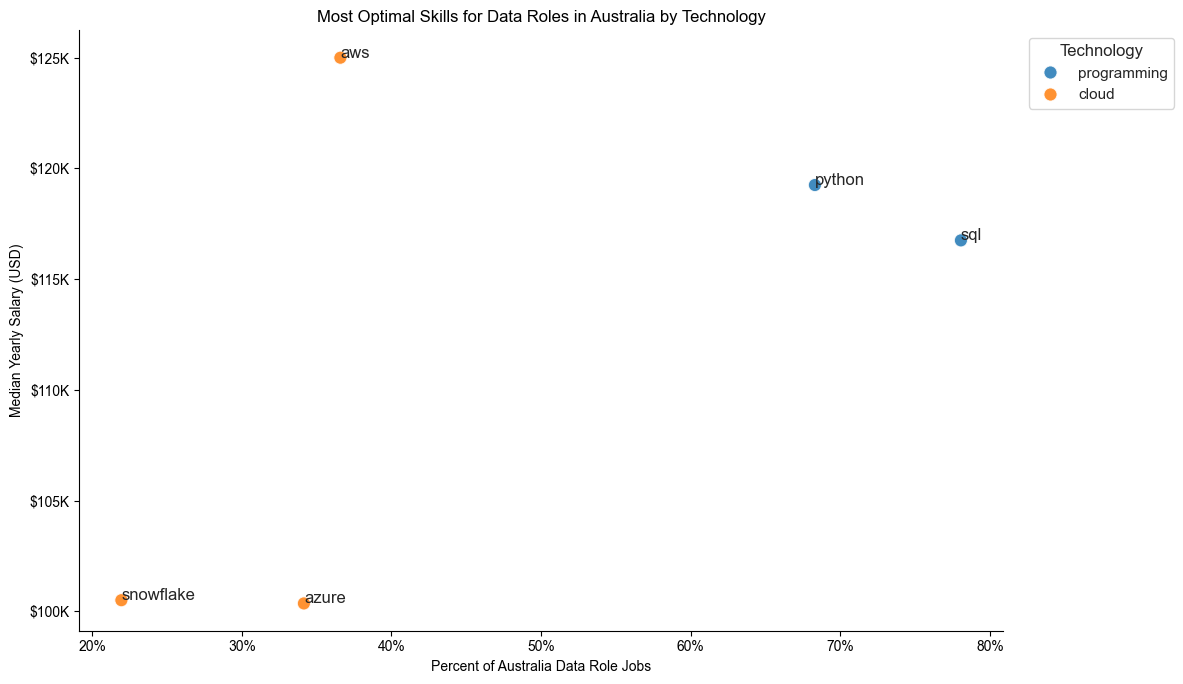

In [11]:
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df_skills_tech_high_demand,
    x='skill_percent',
    y='median_salary',
    hue='technology',
    s=90,
    alpha=0.85
)

sns.despine()
sns.set_theme(style='ticks')

# label top skills by demand so the chart stays readable
label_df = df_skills_tech_high_demand.sort_values('skill_percent', ascending=False).head(12)
texts = []
for _, row in label_df.iterrows():
    texts.append(plt.text(row['skill_percent'], row['median_salary'], row['job_skills']))

if adjust_text is not None:
    adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

plt.xlabel('Percent of Australia Data Role Jobs')
plt.ylabel('Median Yearly Salary (USD)')
plt.title('Most Optimal Skills for Data Roles in Australia by Technology')
plt.legend(title='Technology', bbox_to_anchor=(1.02, 1), loc='upper left')

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

plt.tight_layout()
plt.show()
